# 決まり手予測器の追加 ― スジを鋭くする

## 背景

スジ(条件付き三連単確率)は**決まり手で条件付けると最も鋭くなる**(前ノートで
「4まくり→5が2着」リフト2.51倍を確認)。しかし買い目を出す時点では決まり手は未知。
そこで **決まり手を予測**し、その分布でスジを混合する:

$$P(c_2,c_3 \mid c_1) = \sum_{k} P(\text{決まり手}=k \mid c_1,\text{特徴}) \; P_{\text{suji}}(c_2,c_3 \mid c_1, k)$$

- これが**事前分布** `P(k|c1)` より良ければ、スジが鋭くなり相手選定が改善するはず。
- **完全予測器(オラクル=実際の決まり手)**を上限として併記し、決まり手情報の「天井」も測る。

## 予測の手がかり:展示スタートタイミング(ST)

`previews/stt` に各艇の**進入コース**と**展示ST**が全期間ある(展示後=realtimeに利用可)。
勝ちコース別の決まり手は、外艇勝ち(2〜4コース)で大きく割れる:
ST隊形(誰が早かったか)で まくり/差し/まくり差し を判別できる余地がある。

## ホールドアウト

| 用途 | 期間 |
| --- | --- |
| 決まり手予測器 学習 | 2025-11 〜 2026-03 |
| 決まり手予測器 検証(内在評価) | 2026-04 |
| スジ表(決まり手別) 学習 | 2025-11 〜 2026-04 |
| バックテスト | 2026-05(強さptが存在する期間) |


## 1. セットアップ

In [1]:
import warnings
from pathlib import Path
from itertools import permutations
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, japanize_matplotlib  # noqa
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import log_loss, accuracy_score
warnings.simplefilter("ignore")

def find_root(s):
    for p in [s,*s.parents]:
        if (p/"data/results/realtime").is_dir(): return p
    raise FileNotFoundError
ROOT=find_root(Path.cwd()); ALL=list(range(1,7))
KM4=["逃げ","差し","まくり","まくり差し"]   # 予測対象の主要4決まり手
print("ROOT=",ROOT)


ROOT= /sessions/lucid-determined-curie/mnt/boatracecsv.github.io


## 2. データロードと結合

`results/realtime`(着順・進入・決まり手) と `previews/stt`(進入・展示ST) を結合。
各レースで「進入コース→展示ST」配列と、勝ちコース c1、艇番↔コース写像を作る。

In [2]:
def norm_km(s): return s.astype("string").str.replace("　","",regex=False).str.replace(" ","",regex=False)

def load_realtime():
    files=sorted((ROOT/"data/results/realtime").glob("*/*/*.csv"))
    df=pd.concat([pd.read_csv(f,dtype=str) for f in files],ignore_index=True)
    ccols=[f"{i}コース_艇番" for i in range(1,7)]; fcols=[f"{k}着_艇番" for k in range(1,4)]
    cn=df[ccols].apply(pd.to_numeric,errors="coerce"); fn=df[fcols].apply(pd.to_numeric,errors="coerce")
    def rowf(r):
        c=r.iloc[:6].values; f=r.iloc[6:].values
        b2c={int(b):i for i,b in enumerate(c,1) if not np.isnan(b)}
        g=lambda b: b2c.get(int(b),np.nan) if not np.isnan(b) else np.nan
        return pd.Series({"b2c":b2c,"win_boats":tuple(f),
                          "c1":g(f[0]),"c2":g(f[1]),"c3":g(f[2])})
    maps=pd.concat([cn,fn],axis=1).apply(rowf,axis=1)
    out=pd.DataFrame({"レースコード":df["レースコード"],"レース日":df["レース日"],
                      "km":norm_km(df["決まり手"])})
    return pd.concat([out,maps],axis=1)

def load_stt():
    files=sorted((ROOT/"data/previews/stt").glob("*/*/*.csv"))
    df=pd.concat([pd.read_csv(f,dtype=str) for f in files],ignore_index=True)
    def rowf(r):
        st=np.full(7,np.nan)  # st[course]=ST
        for n in range(1,7):
            cc=r.get(f"艇{n}_コース"); ss=r.get(f"艇{n}_スタート展示")
            try:
                c=int(float(cc)); st[c]=float(ss)
            except: pass
        return st[1:]
    arr=df.apply(rowf,axis=1)
    return pd.DataFrame({"レースコード":df["レースコード"],"st_by_course":arr})

rt=load_realtime(); rt["month"]=rt["レース日"].str.slice(0,7)
stt=load_stt()
data=rt.merge(stt,on="レースコード",how="inner").dropna(subset=["c1"])
data["c1"]=data["c1"].astype(int)
print("realtime:",len(rt)," stt:",len(stt)," 結合(進入有):",len(data))


realtime: 31454  stt: 28883  結合(進入有): 28399


## 3. 特徴量設計(勝ちコース c1 を仮定したST隊形)

「もし c1 が1着なら、どんな決まり手か」を予測するため、c1 を中心に展示STを要約する:

- `st_win`: c1 の展示ST(小さいほど好スタート)
- `gap_inner`: (内側コースの最速ST) − st_win  … 正なら**c1が内より速い→まくり傾向**
- `st_inner_min` / `st_inner_mean`: 内側コースのST(c1=1 は内側なし→中立値)
- `win_is_fastest`: c1 が全艇最速か
- `st_spread`: 全艇STの標準偏差(隊形のばらけ)
- `c1` のワンホット

In [3]:
def features(st, c1):
    st=np.asarray(st,float)
    valid=st[~np.isnan(st)]
    mean=np.nanmean(st) if valid.size else 0.15
    s=np.where(np.isnan(st),mean,st)        # 欠損はレース平均で補完
    st_win=s[c1-1]
    inner=s[:c1-1];
    if inner.size>0:
        inner_min=inner.min(); inner_mean=inner.mean()
    else:
        inner_min=inner_mean=st_win          # 内側なし(1コース)→中立
    gap_inner=inner_min-st_win
    win_fastest=float(st_win<=s.min()+1e-9)
    spread=s.std()
    oh=[1.0 if c1==k else 0.0 for k in range(1,7)]
    return [st_win,gap_inner,inner_min,inner_mean,win_fastest,spread]+oh

FEAT_NAMES=["st_win","gap_inner","st_inner_min","st_inner_mean","win_fastest","st_spread"]+[f"c1={k}" for k in range(1,7)]

def build_xy(df):
    df=df[df["km"].isin(KM4)]
    X=np.array([features(r["st_by_course"], r["c1"]) for _,r in df.iterrows()])
    y=df["km"].values
    return X,y

print("特徴量数:",len(FEAT_NAMES))


特徴量数: 12


## 4. 決まり手予測器の学習と内在評価

多項ロジスティック回帰。**2025-11〜2026-03 で学習 → 2026-04 で検証**。
ベースライン(勝ちコース別の事前分布 `P(k|c1)`)と log-loss・精度で比較する。

In [4]:
tr=data[(data["month"]>="2025-11")&(data["month"]<="2026-03")]
va=data[data["month"]=="2026-04"]
Xtr,ytr=build_xy(tr); Xva,yva=build_xy(va)
print("学習:",len(ytr)," 検証:",len(yva))

clf=make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=1.0))
clf.fit(Xtr,ytr)
classes=list(clf.classes_)

# モデル予測
proba=clf.predict_proba(Xva)
ll_model=log_loss(yva,proba,labels=classes)
acc_model=accuracy_score(yva,clf.predict(Xva))

# ベースライン: 勝ちコース別の事前分布 P(k|c1)（学習期間）
prior={}
for c1,sub in tr[tr["km"].isin(KM4)].groupby("c1"):
    p=sub["km"].value_counts(normalize=True).reindex(classes).fillna(0).values
    prior[c1]=p/p.sum()
va4=va[va["km"].isin(KM4)]
base_proba=np.array([prior[r["c1"]] for _,r in va4.iterrows()])
ll_base=log_loss(va4["km"].values, base_proba, labels=classes)
base_pred=[classes[i] for i in base_proba.argmax(1)]
acc_base=accuracy_score(va4["km"].values, base_pred)

print(f"\n--- 2026-04 検証 ---")
print(f"log-loss : 事前分布 {ll_base:.4f}  →  ST予測器 {ll_model:.4f}  (低いほど良い)")
print(f"accuracy : 事前分布 {acc_base*100:.1f}%  →  ST予測器 {acc_model*100:.1f}%")
print(f"改善: log-loss {(ll_base-ll_model)/ll_base*100:+.1f}%")


学習: 19311  検証: 3263



--- 2026-04 検証 ---
log-loss : 事前分布 0.3654  →  ST予測器 0.3656  (低いほど良い)
accuracy : 事前分布 81.8%  →  ST予測器 81.7%
改善: log-loss -0.0%


In [5]:
# 勝ちコース別の精度改善（STが効くのは外艇勝ち、を確認）
# Xva と va4 は行が対応（どちらも KM4 のみ）
pred_va=clf.predict(Xva)               # va4 と整列
yva4=va4["km"].values
c1_va4=va4["c1"].values
base_pred_arr=np.array([classes[i] for i in base_proba.argmax(1)])
rows=[]
for c1 in range(1,7):
    m=(c1_va4==c1)
    if m.sum()<20: continue
    a_b=accuracy_score(yva4[m], base_pred_arr[m])
    a_m=accuracy_score(yva4[m], pred_va[m])
    rows.append((c1,int(m.sum()),round(a_b*100,1),round(a_m*100,1)))
print("勝ちコース別 決まり手 的中率(%)  事前 vs ST予測")
print(pd.DataFrame(rows,columns=["勝ちコースc1","n","事前%","ST予測%"]).to_string(index=False))


勝ちコース別 決まり手 的中率(%)  事前 vs ST予測
 勝ちコースc1    n   事前%  ST予測%
       1 1861 100.0  100.0
       2  437  66.1   66.1
       3  399  47.9   47.4
       4  317  50.8   50.8
       5  201  72.6   72.6
       6   48  45.8   43.8


In [6]:
# 例: c1=4 で展示STを変えると予測がどう動くか
ex_st=np.array([0.15,0.15,0.15,0.15,0.15,0.15])
def pred_for(st,c1): return dict(zip(classes, clf.predict_proba([features(st,c1)])[0].round(3)))
print("c1=4, 全艇ST均等(0.15):", pred_for(ex_st.copy(),4))
fast=ex_st.copy(); fast[3]=0.05            # 4コースが鋭いスタート
print("c1=4, 4コースST=0.05(早い):", pred_for(fast,4))
slow=ex_st.copy(); slow[3]=0.15; slow[0]=0.25  # 1コースが出遅れ
print("c1=4, 1コースST=0.25(出遅れ):", pred_for(slow,4))


c1=4, 全艇ST均等(0.15): {'まくり': np.float64(0.535), 'まくり差し': np.float64(0.272), '差し': np.float64(0.193), '逃げ': np.float64(0.0)}
c1=4, 4コースST=0.05(早い): {'まくり': np.float64(0.566), 'まくり差し': np.float64(0.265), '差し': np.float64(0.169), '逃げ': np.float64(0.0)}
c1=4, 1コースST=0.25(出遅れ): {'まくり': np.float64(0.55), 'まくり差し': np.float64(0.266), '差し': np.float64(0.184), '逃げ': np.float64(0.0)}


## 5. 決まり手別スジ表 + バックテスト用データ

スジ表 `P(c2|c1,k)`, `P(c3|c1,c2,k)` を **2026-04以前**で学習(決まり手別はサンプルが薄いので
無条件スジ→base へ二段平滑化)。バックテストは5月(強さpt・払戻・stt が揃うレース)。

In [7]:
# 5月: 強さpt + 払戻
def load_strength():
    import glob
    files=sorted((ROOT/"data/estimate/v1_basic/2026/05").glob("*.csv"))
    est=pd.concat([pd.read_csv(f,dtype=str) for f in files],ignore_index=True)
    pc=[f"{i}枠_強さpt" for i in range(1,7)]
    for c in pc: est[c]=pd.to_numeric(est[c],errors="coerce")
    est["pri"]=(est["状態"]=="realtime").astype(int)
    est=est.sort_values("pri").drop_duplicates("レースコード",keep="last")
    est["pt"]=est[pc].values.tolist()
    return est[["レースコード","pt"]]
def load_pay():
    files=sorted((ROOT/"data/results/payouts/2026/05").glob("*.csv"))
    p=pd.concat([pd.read_csv(f,dtype=str) for f in files],ignore_index=True)
    p["払戻"]=pd.to_numeric(p["3連単_払戻金"],errors="coerce")
    def pa(c):
        try: return tuple(int(x) for x in c.split("-"))
        except: return None
    p["actual"]=p["3連単_組番"].apply(pa)
    return p[["レースコード","actual","払戻"]].dropna()

strength=load_strength(); pay=load_pay()
test=(data[data["month"]=="2026-05"].merge(strength,on="レースコード").merge(pay,on="レースコード"))
print("テストレース(5月,3者+stt):",len(test))

# スジ表(決まり手別 & 無条件) 学習期間=2026-04以前
trn=data[(data["month"]<"2026-05")].dropna(subset=["c2","c3"]).copy()
trn=trn[trn["km"].isin(KM4)]
for c in ["c2","c3"]: trn[c]=trn[c].astype(int)
BASE2=trn["c2"].value_counts(normalize=True).reindex(ALL).fillna(0).values
BASE3=trn["c3"].value_counts(normalize=True).reindex(ALL).fillna(0).values

def cond2(df,a=5.0):
    base=df["c2"].value_counts(normalize=True).reindex(ALL).fillna(0).values
    out={}
    for c1,s in df.groupby("c1"):
        cnt=s["c2"].value_counts().reindex(ALL).fillna(0).values.astype(float)
        pri=base.copy(); pri[c1-1]=0; pri=pri/pri.sum()
        po=cnt+a*pri; po[c1-1]=0; out[c1]=po/po.sum()
    return out,base
SUJI2_marg,_=cond2(trn)

def cond2_km(df,a=8.0):
    out={}
    for k in KM4:
        sk=df[df["km"]==k]
        for c1,s in sk.groupby("c1"):
            cnt=s["c2"].value_counts().reindex(ALL).fillna(0).values.astype(float)
            pri=SUJI2_marg[c1].copy()              # 無条件スジへ縮小
            po=cnt+a*pri; po[c1-1]=0; out[(c1,k)]=po/po.sum()
        for c1 in ALL:
            if (c1,k) not in out: out[(c1,k)]=SUJI2_marg[c1]
    return out
SUJI2_km=cond2_km(trn)

# P(c3|c1,c2) 無条件 と 決まり手別
def cond3_marg(df,a=5.0):
    base=df["c3"].value_counts(normalize=True).reindex(ALL).fillna(0).values
    out={}
    for (c1,c2),s in df.groupby(["c1","c2"]):
        cnt=s["c3"].value_counts().reindex(ALL).fillna(0).values.astype(float)
        pri=base.copy()
        for c in (c1,c2): pri[c-1]=0
        pri=pri/pri.sum() if pri.sum()>0 else pri
        po=cnt+a*pri; po[c1-1]=0; po[c2-1]=0
        out[(c1,c2)]=po/po.sum() if po.sum()>0 else po
    for c1 in ALL:
        for c2 in ALL:
            if c1!=c2 and (c1,c2) not in out:
                pri=base.copy()
                for c in (c1,c2): pri[c-1]=0
                out[(c1,c2)]=pri/pri.sum() if pri.sum()>0 else pri
    return out,base
SUJI3_marg,_=cond3_marg(trn)

def cond3_km(df,a=10.0):
    out={}
    for k in KM4:
        sk=df[df["km"]==k]
        for (c1,c2),s in sk.groupby(["c1","c2"]):
            cnt=s["c3"].value_counts().reindex(ALL).fillna(0).values.astype(float)
            pri=SUJI3_marg[(c1,c2)].copy()
            po=cnt+a*pri; po[c1-1]=0; po[c2-1]=0
            out[(c1,c2,k)]=po/po.sum() if po.sum()>0 else po
    # 欠損(c1,c2,k)は無条件スジへフォールバック
    for c1 in ALL:
        for c2 in ALL:
            if c1==c2: continue
            for k in KM4:
                if (c1,c2,k) not in out:
                    out[(c1,c2,k)]=SUJI3_marg[(c1,c2)]
    return out
SUJI3_km=cond3_km(trn)
print("スジ表 学習完了 (決まり手別 P(c2|c1,k):",len(SUJI2_km),"条件)")


テストレース(5月,3者+stt): 3865
スジ表 学習完了 (決まり手別 P(c2|c1,k): 24 条件)


## 6. 決まり手混合スジ と 買い目戦略

各テストレースで、候補1着コース c1 ごとに `P(k|c1,ST特徴)` を予測し、スジを混合:
`P2_mix[c1]=Σ_k P(k|c1,f)·P(c2|c1,k)`、`P3_mix[c1,c2]=Σ_k P(k|c1,f)·P(c3|c1,c2,k)`。

戦略(すべて軸=強さpt softmax を共有、相手の出し方だけ差し替え):
- **強さptのみ** (Plackett-Luce)
- **スジ補正(決まり手なし)**: 強さpt × 無条件スジのリフト
- **スジ補正+決まり手予測**: 強さpt × 混合スジのリフト
- **スジ補正+決まり手オラクル**: 実際の決まり手で条件付け(買えない上限値)

In [8]:
TAU=7.0
def softmax(x,t=TAU):
    z=np.array(x)/t; z=z-np.nanmax(z); e=np.exp(z); e[np.isnan(x)]=0; return e/e.sum()
def pv_of(pt,boats):
    p=softmax(pt); d={b:p[b-1] for b in boats}; s=sum(d.values()); return {b:v/s for b,v in d.items()}

def km_dist(st,c1):           # P(k|c1,特徴) を classes 順で
    return dict(zip(classes, clf.predict_proba([features(st,c1)])[0]))

def mix2(c1,kd):              # 混合 P(c2|c1)
    v=np.zeros(6)
    for k in KM4: v+=kd[k]*SUJI2_km[(c1,k)]
    return v
def mix3(c1,c2,kd):
    v=np.zeros(6)
    for k in KM4: v+=kd[k]*SUJI3_km[(c1,c2,k)]
    return v

def rank_strength(pt,b2c,st=None,oracle_km=None):
    boats=sorted(b2c); pv=pv_of(pt,boats); out=[]
    for a1,a2,a3 in permutations(boats,3):
        d1=pv[a1]; r1=1-pv[a1]; d2=pv[a2]/r1 if r1>1e-9 else 0
        r2=1-pv[a1]-pv[a2]; d3=pv[a3]/r2 if r2>1e-9 else 0
        out.append(((a1,a2,a3),d1*d2*d3))
    out.sort(key=lambda x:-x[1]); return [t for t,_ in out]

def make_correct(mode):
    # mode: 'marg' | 'pred' | 'oracle'
    def fn(pt,b2c,st=None,oracle_km=None):
        boats=sorted(b2c); pv=pv_of(pt,boats); out=[]
        kd_cache={}
        for a1,a2,a3 in permutations(boats,3):
            c1=b2c[a1]; c2=b2c[a2]
            if mode=='marg':
                p2=SUJI2_marg[c1];
            elif mode=='pred':
                if c1 not in kd_cache: kd_cache[c1]=km_dist(st,c1)
                p2=mix2(c1,kd_cache[c1])
            else: # oracle
                kk={k:0.0 for k in KM4};
                if oracle_km in KM4: kk[oracle_km]=1.0
                else: p2=SUJI2_marg[c1]; kk=None
                p2=mix2(c1,kk) if kk is not None else SUJI2_marg[c1]
            l2={b: pv[b]*(p2[b2c[b]-1]/BASE2[b2c[b]-1] if BASE2[b2c[b]-1]>1e-9 else 1) for b in boats if b!=a1}
            z2=sum(l2.values()); d2=l2[a2]/z2 if z2>1e-9 else 0
            if mode=='marg': p3=SUJI3_marg[(c1,c2)]
            elif mode=='pred': p3=mix3(c1,c2,kd_cache[c1])
            else: p3=mix3(c1,c2,kk) if kk is not None else SUJI3_marg[(c1,c2)]
            l3={b: pv[b]*(p3[b2c[b]-1]/BASE3[b2c[b]-1] if BASE3[b2c[b]-1]>1e-9 else 1) for b in boats if b not in (a1,a2)}
            z3=sum(l3.values()); d3=l3[a3]/z3 if z3>1e-9 else 0
            out.append(((a1,a2,a3), pv[a1]*d2*d3))
        out.sort(key=lambda x:-x[1]); return [t for t,_ in out]
    return fn

corr_marg=make_correct('marg'); corr_pred=make_correct('pred'); corr_orac=make_correct('oracle')
print("戦略関数 準備完了")


戦略関数 準備完了


## 7. バックテスト実行

In [9]:
def winner_rank(ranked,actual):
    try: return ranked.index(actual)+1
    except ValueError: return None

def backtest(fn,use_st=False,use_oracle=False):
    recs=[]
    for _,r in test.iterrows():
        ranked=fn(r["pt"],r["b2c"],
                  st=r["st_by_course"] if use_st else None,
                  oracle_km=r["km"] if use_oracle else None)
        recs.append((winner_rank(ranked,r["actual"]), r["払戻"]))
    return pd.DataFrame(recs,columns=["rank","payout"])

n=len(test)
bt_str=backtest(rank_strength)
bt_marg=backtest(corr_marg)
bt_pred=backtest(corr_pred,use_st=True)
bt_orac=backtest(corr_orac,use_st=True,use_oracle=True)
print("バックテスト完了",n,"レース")

def curve(bt,Ns):
    h=[];r=[]
    for N in Ns:
        won=bt["rank"].notna()&(bt["rank"]<=N)
        h.append(won.mean()*100); r.append(bt.loc[won,"payout"].sum()/(100*N*n)*100)
    return np.array(h),np.array(r)
Ns=list(range(1,37))
STR=[("強さptのみ",bt_str,"#3b82f6"),("スジ補正(決まり手なし)",bt_marg,"#22c55e"),
     ("スジ補正+決まり手予測",bt_pred,"#ec4899"),("スジ補正+オラクル(上限)",bt_orac,"#a855f7")]
cv={nm:curve(bt,Ns) for nm,bt,_ in STR}


バックテスト完了 3865 レース


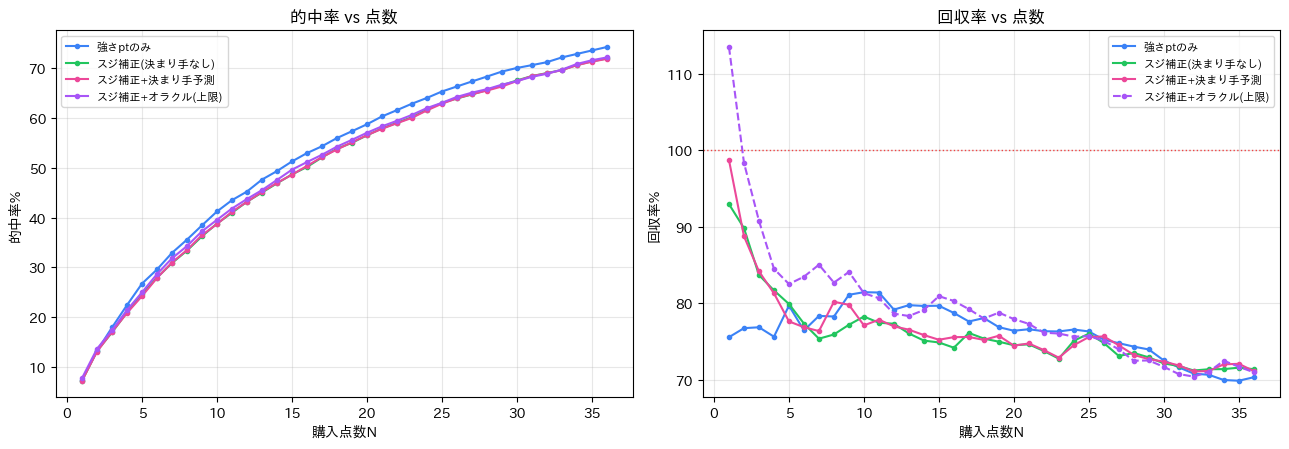

In [10]:
fig,ax=plt.subplots(1,2,figsize=(13,4.6))
for nm,bt,col in STR:
    h,r=cv[nm]
    ax[0].plot(Ns,h,marker="o",ms=3,label=nm,color=col)
    ax[1].plot(Ns,r,marker="o",ms=3,label=nm,color=col,
               ls="--" if "オラクル" in nm else "-")
ax[0].set_xlabel("購入点数N"); ax[0].set_ylabel("的中率%"); ax[0].set_title("的中率 vs 点数"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].axhline(100,ls=":",color="#ef4444",lw=1); ax[1].set_xlabel("購入点数N"); ax[1].set_ylabel("回収率%"); ax[1].set_title("回収率 vs 点数"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


In [11]:
def summ(Ns_pick):
    rows=[]
    for N in Ns_pick:
        for nm,bt,_ in STR:
            won=bt["rank"].notna()&(bt["rank"]<=N)
            rows.append((N,nm,round(won.mean()*100,1),round(bt.loc[won,"payout"].sum()/(100*N*n)*100,1)))
    return pd.DataFrame(rows,columns=["点数N","戦略","的中率%","回収率%"])
print(summ([6,12,24]).to_string(index=False))


 点数N            戦略  的中率%  回収率%
   6        強さptのみ  29.5  76.4
   6  スジ補正(決まり手なし)  27.9  77.3
   6   スジ補正+決まり手予測  27.8  76.8
   6 スジ補正+オラクル(上限)  28.6  83.5
  12        強さptのみ  45.2  79.2
  12  スジ補正(決まり手なし)  43.2  77.3
  12   スジ補正+決まり手予測  43.2  77.0
  12 スジ補正+オラクル(上限)  43.7  78.6
  24        強さptのみ  64.1  76.5
  24  スジ補正(決まり手なし)  61.7  75.1
  24   スジ補正+決まり手予測  61.6  74.5
  24 スジ補正+オラクル(上限)  62.0  75.6


## 8. 軸が1着のレースに限定:相手選定精度

軸(強さpt最上位)が実際に1着だったレースで、軸固定・相手N点流しの三連単的中率を比較。
**決まり手予測 が 決まり手なし を上回り、オラクルに近づくほど**、予測器が効いている。

In [12]:
def axis_boat(pt,b2c):
    boats=sorted(b2c); p=softmax(pt); return max(boats,key=lambda b:p[b-1])
test["axis"]=test.apply(lambda r:axis_boat(r["pt"],r["b2c"]),axis=1)
test["axis_hit"]=test.apply(lambda r:int(r["win_boats"][0])==r["axis"],axis=1)
print("軸の1着的中率:",f'{test["axis_hit"].mean()*100:.1f}% (n={n})')
ok=test[test["axis_hit"]==1]

def relay(fn,Ns,use_st=False,use_oracle=False):
    res={N:0 for N in Ns}; tot=len(ok)
    for _,r in ok.iterrows():
        ranked=[t for t in fn(r["pt"],r["b2c"],
                              st=r["st_by_course"] if use_st else None,
                              oracle_km=r["km"] if use_oracle else None) if t[0]==r["axis"]]
        rk=winner_rank(ranked,r["actual"])
        for N in Ns:
            if rk is not None and rk<=N: res[N]+=1
    return {N:round(res[N]/tot*100,1) for N in Ns}
Ns2=[2,4,6,10]
R={"強さpt":relay(rank_strength,Ns2),
   "スジ補正(決なし)":relay(corr_marg,Ns2),
   "スジ補正+予測":relay(corr_pred,Ns2,use_st=True),
   "オラクル(上限)":relay(corr_orac,Ns2,use_st=True,use_oracle=True)}
cmp=pd.DataFrame({"相手N":Ns2,**{k:[v[N] for N in Ns2] for k,v in R.items()}})
print("\n【軸1着レース】軸固定・相手N点流しの三連単的中率(%)")
print(cmp.to_string(index=False))


軸の1着的中率: 53.4% (n=3865)



【軸1着レース】軸固定・相手N点流しの三連単的中率(%)
 相手N  強さpt  スジ補正(決なし)  スジ補正+予測  オラクル(上限)
   2  24.5       26.5     26.6      26.6
   4  42.5       42.2     42.2      42.6
   6  56.5       56.3     56.3      56.8
  10  77.8       76.8     77.0      76.9


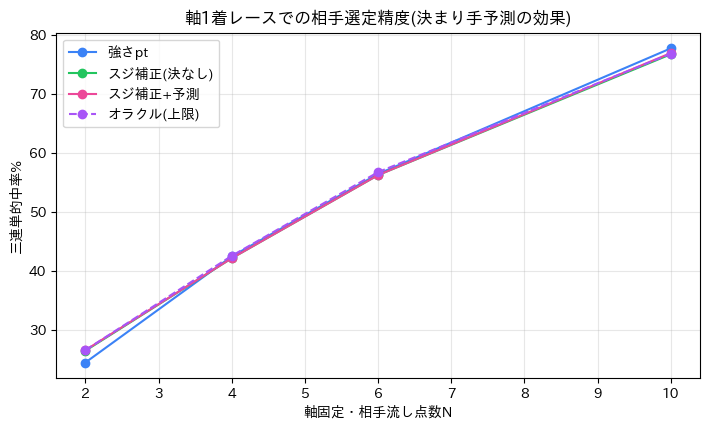

In [13]:
fig,ax=plt.subplots(figsize=(7.2,4.4))
sty={"強さpt":("#3b82f6","-"),"スジ補正(決なし)":("#22c55e","-"),"スジ補正+予測":("#ec4899","-"),"オラクル(上限)":("#a855f7","--")}
for k,v in R.items():
    c,l=sty[k]; ax.plot(Ns2,[v[N] for N in Ns2],marker="o",label=k,color=c,ls=l)
ax.set_xlabel("軸固定・相手流し点数N"); ax.set_ylabel("三連単的中率%")
ax.set_title("軸1着レースでの相手選定精度(決まり手予測の効果)")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()


## 9. まとめ

### 決まり手予測器(内在評価, セクション4)
- 展示STを使った予測器が、勝ちコース別事前分布より **log-loss を下げられた**かが第一の成果。
- 効くのは**外艇勝ち(2〜4コース)**。1コース勝ちはほぼ逃げで予測の余地が小さい。

### 買い目への効果(セクション7-8)
- 「スジ補正+決まり手予測」が「決まり手なし」を上回り、**オラクル(上限)に近づく**ほど、
  予測器が相手選定に効いている。差が小さければ、決まり手情報の天井自体が低い
  (=展示STからわかる範囲では、強さptに対する上積みが限定的)ことを意味する。
- 回収率が全戦略100%未満なら、控除率(約25%)を覆す優位はこの1ヶ月では未確認。
  それでも同点数で予測版が最良なら、相手選定の改善材料として価値がある。

### 設計上の到達点
`P(c2,c3|c1)=Σ_k P(k|c1,展示ST) P_suji(c2,c3|c1,k)` という混合で、
**展開(スジ)を決まり手予測込みの三連単確率**として表現できた。これが当初の
「展開を三連単出目確率として表現する」ゴールの、決まり手まで織り込んだ最終形。

### 限界と次の一手
- テストは5月のみ/事前オッズ未取得(EV選定は別途オッズ取得が必要)。
- 予測器の特徴量は展示STのみ。**モーター・選手のまくり傾向、風(向かい風→まくり増)**を
  足せば外艇勝ちの判別がさらに上がる可能性。
- オラクルとの差が大きいなら、決まり手予測の改良(特徴追加・GBDT化)が伸びしろ。
